In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [9]:
directorio = "data_sin_SRH"

for archivo in os.listdir(directorio):
    if archivo.endswith(".npy"):
        nombre = os.path.splitext(archivo)[0]
        ruta = os.path.join(directorio, archivo)

        globals()[nombre] = np.load(ruta)

ejex = x_vector_Efield * 1e4

In [37]:
Wp = 9
Na = 6e15
Nd = 3e15
ni = 1e10

xn_Va_max = 10.1
xp_Va_max = 8.2 #a ojo

idx_xp_Vamax = np.argmin(np.abs(ejex - xp_Va_max))
idx_xn_Vamax = np.argmin(np.abs(ejex - xn_Va_max))

# EXCESOS EN FUNCIÓN DE LA POSICIÓN

(0.0, 8.2)

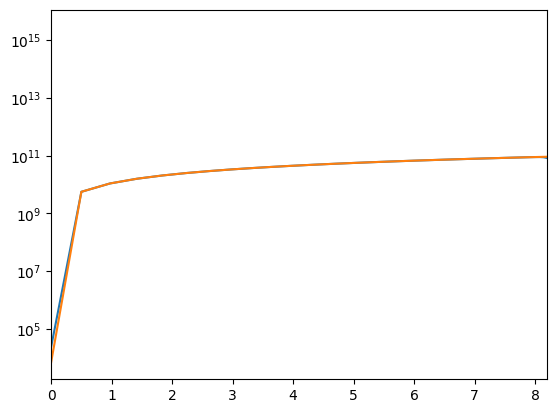

In [46]:
deltap = p_Va_max - Na
deltan = n_Va_max - ni**2/Na
plt.plot(ejex, deltap, label=r'$\Delta p$')
plt.plot(ejex, deltan, label=r'$\Delta n$')
plt.semilogy()
plt.xlim([0, xp_Va_max])

(10.1, 16.0)

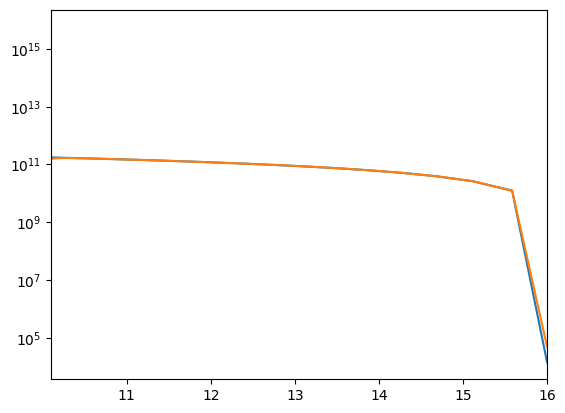

In [38]:
deltap = p_Va_max - ni**2/Nd
deltan = n_Va_max - Nd
plt.plot(ejex, deltap, label=r'$\Delta p$')
plt.plot(ejex, deltan, label=r'$\Delta n$')
plt.semilogy()
plt.xlim([xn_Va_max, 16])

# DIFUSIÓN LADO P

In [88]:
q = 1.602e-19
D_n = 35  #Cm²/s
mu_n = 1350  #Cm²/Vs
D_p = 12.4  #Cm²/s
mu_p = 480  #Cm²/Vs


#difusión huecos
dp_dx_Vamax = np.diff(p_Va_max) / np.diff(ejex * 1e-4)
Jp_diff_Vamax = -q * D_p * dp_dx_Vamax

dn_dx_Vamax = np.diff(n_Va_max) / np.diff(ejex * 1e-4)
Jn_diff_Vamax = q * D_n * dn_dx_Vamax

ejex2 = (ejex[1:] + ejex[:-1]) / 2

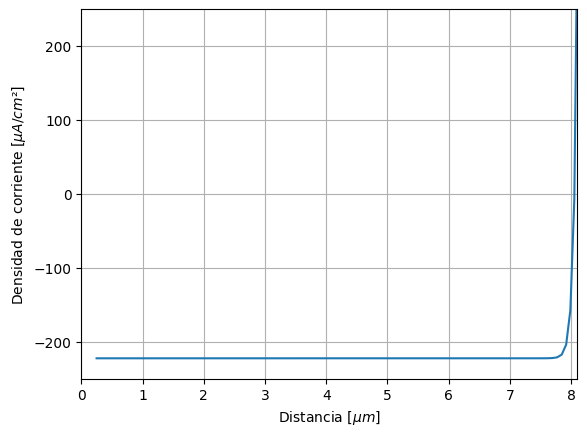

In [90]:
plt.figure()
plt.plot(ejex2[:idx_xp_Vamax], 1e6*Jp_diff_Vamax[:idx_xp_Vamax], label='Difusión de huecos')
#plt.plot(ejex2[:idx_xp_Vamax], 1e6*Jn_diff_Vamax[:idx_xp_Vamax], label='Difusión de electrones')
plt.ylabel(r'Densidad de corriente [$\mu A/cm²$]')
plt.xlabel(r"Distancia [$\mu m$]")
#plt.legend()
plt.ylim([-0.025 * 1e4, 0.025 * 1e4])
plt.xlim([0, 8.1])
plt.grid()

plt.savefig("fig_8_qnr_p.pdf")

In [91]:
Jp_diff_ladoP = np.min(Jp_diff_Vamax[:idx_xp_Vamax]) * 1e6
Jn_diff_ladoP = np.min(Jn_diff_Vamax[:idx_xp_Vamax]) * 1e6
print(f"Corriente de difusión de huecos en el lado P: {Jp_diff_ladoP:.4f} μA/cm²")
print(f"Corriente de difusión de electrones en el lado N: {Jn_diff_ladoP:.4f} μA/cm²")

print(f"Relación entre las corrientes de difusión: {Jp_diff_ladoP/Jn_diff_ladoP:.4f}")
print(f"Relación entre los coeficientes de difusión: {D_p/D_n:.4f}")

Corriente de difusión de huecos en el lado P: -222.3723 μA/cm²
Corriente de difusión de electrones en el lado N: 627.6315 μA/cm²
Relación entre las corrientes de difusión: -0.3543
Relación entre los coeficientes de difusión: 0.3543


# DIFUSIÓN LADO N

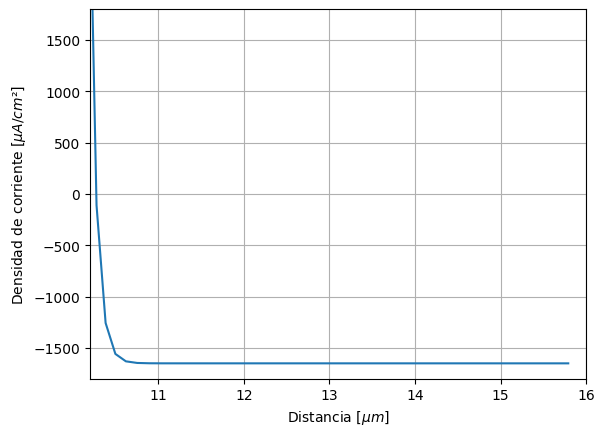

In [93]:
plt.figure()
#plt.plot(ejex2[idx_xn_Vamax:], 1e6*Jp_diff_Vamax[idx_xn_Vamax:], label='Difusión de huecos')
plt.plot(ejex2[idx_xn_Vamax:], 1e6*Jn_diff_Vamax[idx_xn_Vamax:], label='Difusión de electrones')
plt.ylabel(r'Densidad de corriente [$\mu A/cm²$]')
plt.xlabel(r"Distancia [$\mu m$]")
#plt.legend()
plt.ylim([-0.18 * 1e4, 0.18 * 1e4])
plt.xlim([10.2, 16])
plt.grid()

plt.savefig("fig_8_qnr_n.pdf")

In [94]:
Jp_diff_ladoN = np.min(Jp_diff_Vamax[idx_xn_Vamax:]) * 1e6
Jn_diff_ladoN = np.min(Jn_diff_Vamax[idx_xn_Vamax:]) * 1e6
print(f"Corriente de difusión de huecos en el lado N: {Jp_diff_ladoN:.4f} μA/cm²")
print(f"Corriente de difusión de electrones en el lado N: {Jn_diff_ladoN:.4f} μA/cm²")

print(f"Relación entre las corrientes de difusión: {Jp_diff_ladoN/Jn_diff_ladoN:.4f}")
print(f"Relación entre los coeficientes de difusión: {D_p/D_n:.4f}")

Corriente de difusión de huecos en el lado N: 584.6155 μA/cm²
Corriente de difusión de electrones en el lado N: -1650.2375 μA/cm²
Relación entre las corrientes de difusión: -0.3543
Relación entre los coeficientes de difusión: 0.3543
